# DS-Assignment.8 — Logistic Regression on Diabetes Dataset

This notebook includes:
- EDA with **explicit pattern analysis**
- data preprocessing
- logistic regression model building
- model evaluation
- **coefficient significance analysis** using `statsmodels`
- corrected **Streamlit app code**
- answers to the **interview questions**

## 1. Import libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

import joblib

try:
    import statsmodels.api as sm
    HAS_STATSMODELS = True
except Exception:
    HAS_STATSMODELS = False

sns.set(style="whitegrid")

## 2. Load the dataset
Keep `diabetes.csv` in the same folder as this notebook.

In [2]:
file_path = r"C:\Users\D.Anand\Desktop\diabetes\diabetes.csv"
df = pd.read_csv(file_path)

print("Shape:", df.shape)
display(df.head())
print("\nColumns:", list(df.columns))

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


## 3. Basic exploration

In [3]:
print(df.info())
print("\nMissing values (raw):")
print(df.isnull().sum())

print("\nSummary statistics:")
display(df.describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

Missing values (raw):
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Ag

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


## 4. Data cleaning
In this dataset, some medical measurements often use `0` as a placeholder for missing values.
Common columns where zero is invalid:
- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI

In [4]:
df_clean = df.copy()

zero_as_missing_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
existing_zero_cols = [col for col in zero_as_missing_cols if col in df_clean.columns]

for col in existing_zero_cols:
    df_clean[col] = df_clean[col].replace(0, np.nan)

print("Missing values after converting invalid zeros to NaN:")
print(df_clean.isnull().sum())

Missing values after converting invalid zeros to NaN:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


## 5. EDA — visualizations

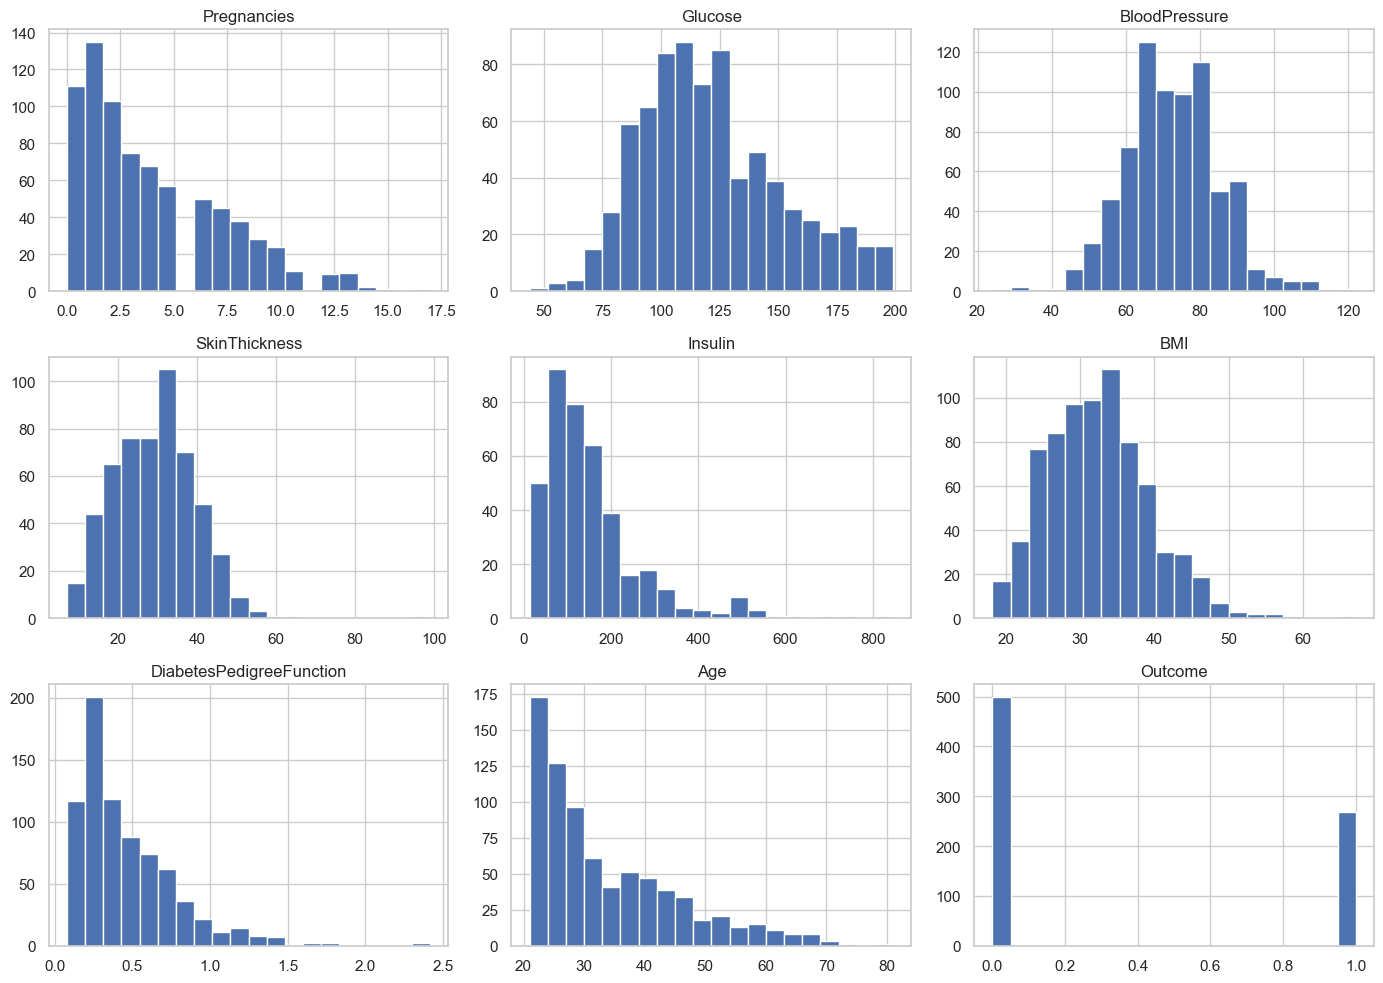

In [5]:
df_clean.hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

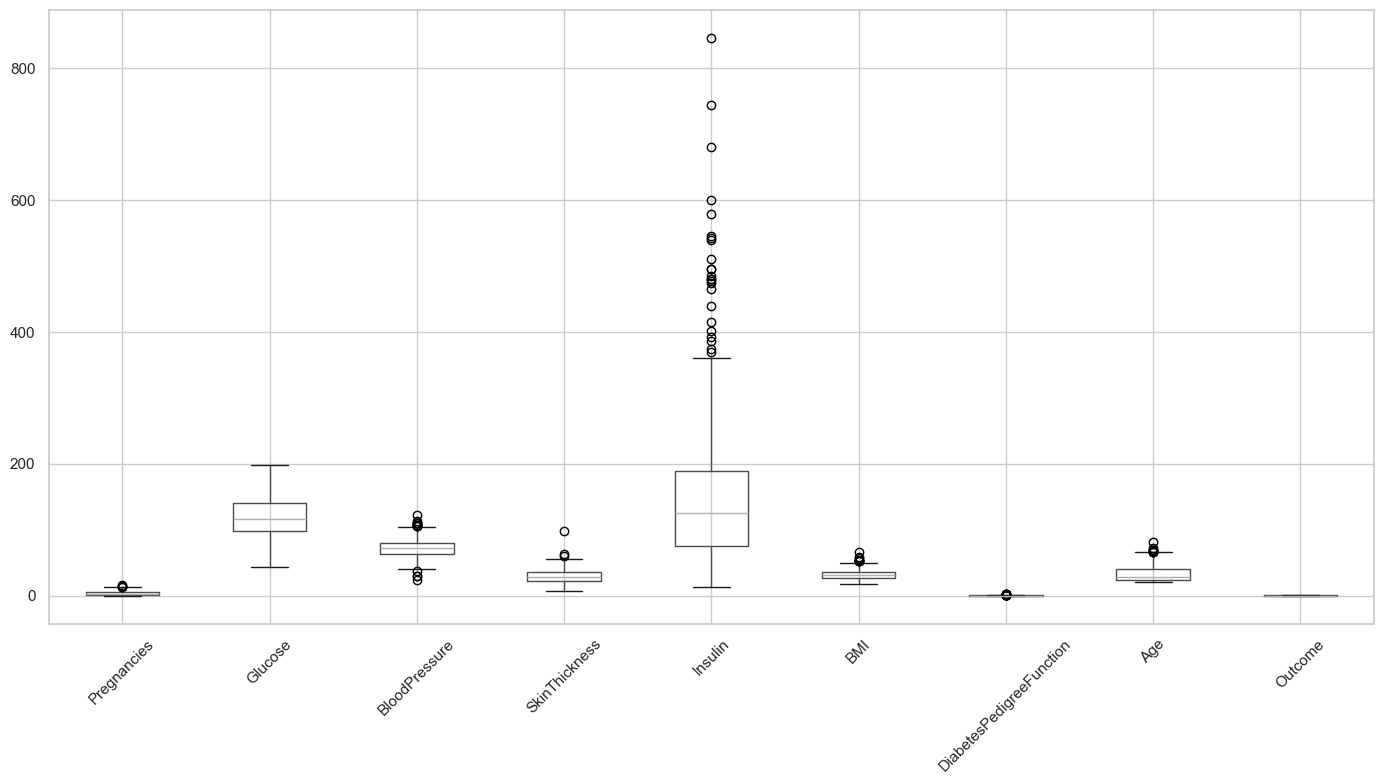

In [6]:
plt.figure(figsize=(14, 8))
df_clean.boxplot(rot=45)
plt.tight_layout()
plt.show()

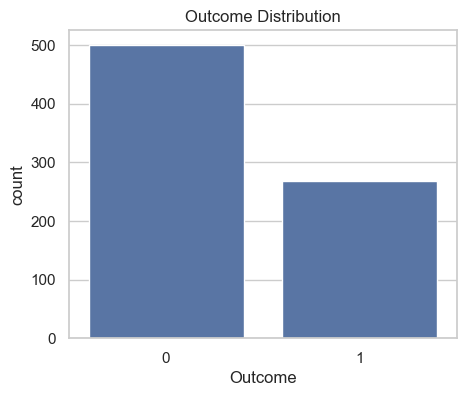

Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


In [7]:
plt.figure(figsize=(5, 4))
sns.countplot(x="Outcome", data=df_clean)
plt.title("Outcome Distribution")
plt.show()

print(df_clean["Outcome"].value_counts(normalize=True).rename("proportion"))

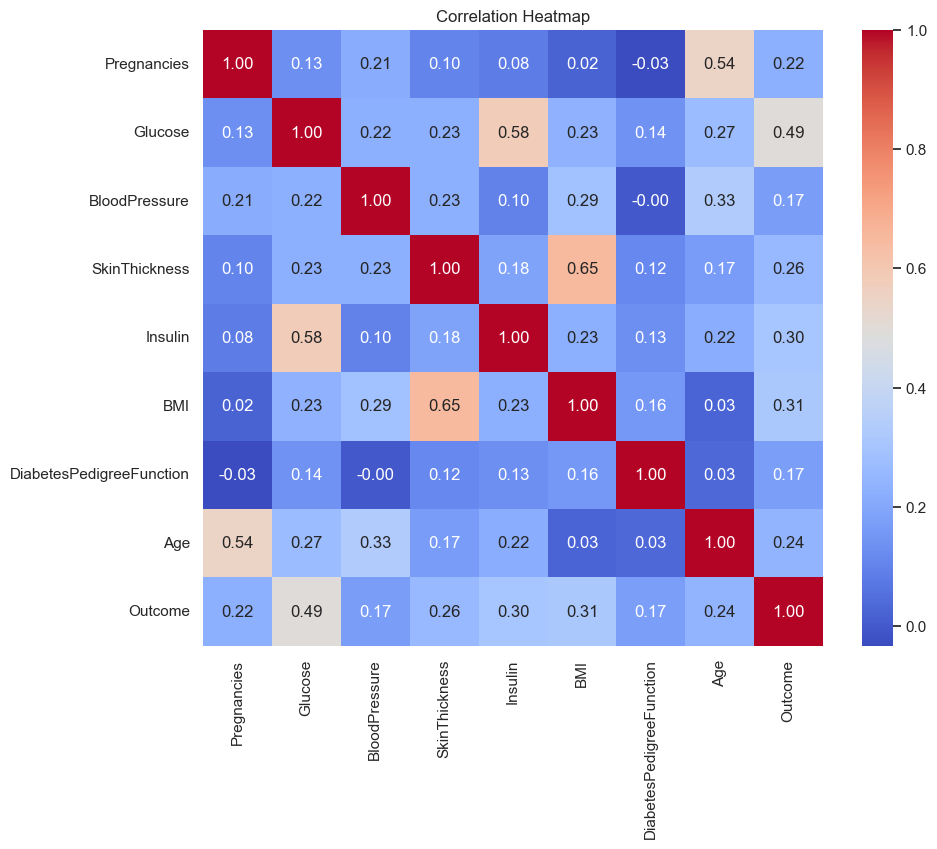

In [8]:
plt.figure(figsize=(10, 8))
corr = df_clean.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

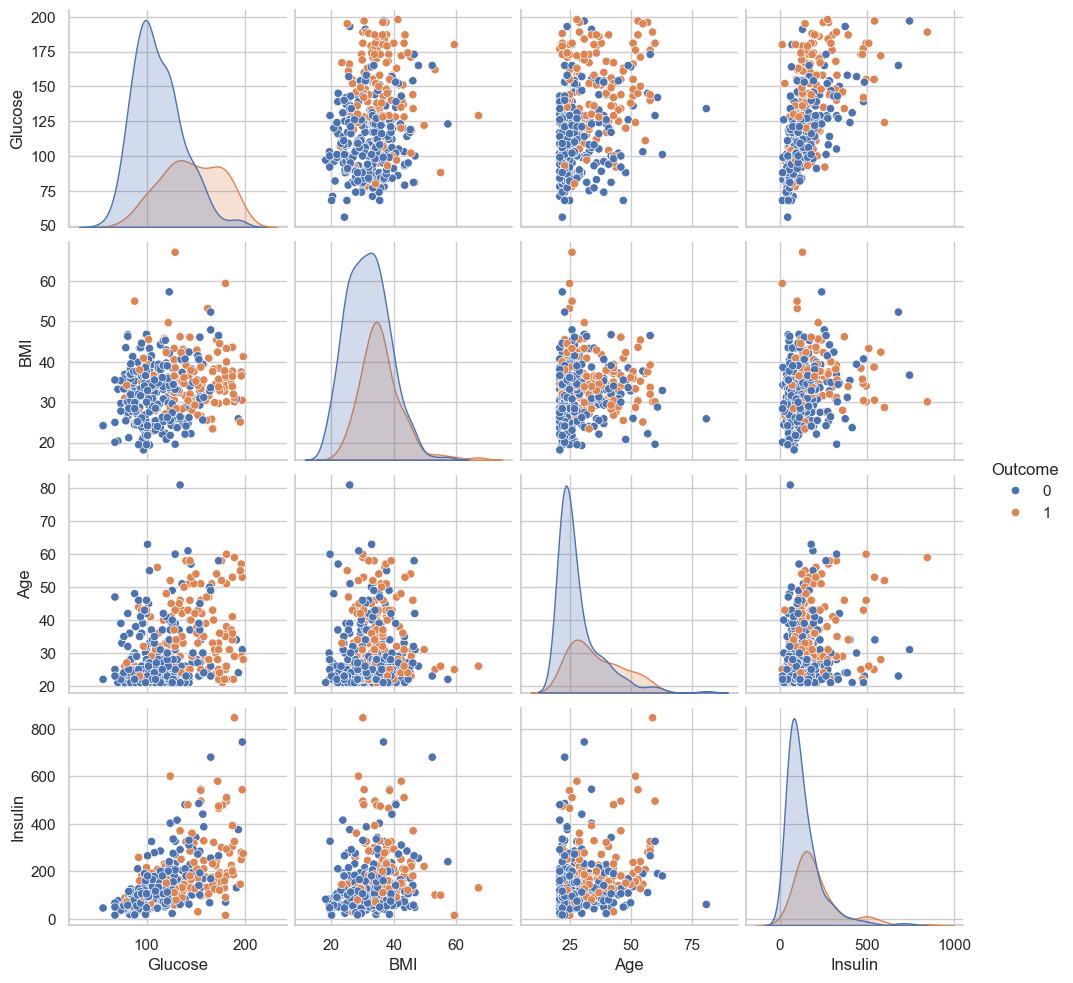

In [9]:
pair_cols = [c for c in ["Glucose", "BMI", "Age", "Insulin", "Outcome"] if c in df_clean.columns]
if len(pair_cols) >= 3:
    sns.pairplot(df_clean[pair_cols].dropna(), hue="Outcome" if "Outcome" in pair_cols else None)
    plt.show()

## 6. Explicit EDA pattern analysis

### Observed patterns
- **Glucose** usually shows a strong positive relationship with diabetes outcome. Patients with higher glucose tend to fall more often in the positive class.
- **BMI** often appears moderately associated with outcome, suggesting higher body mass may raise diabetes risk.
- **Age** can also show a positive pattern, where older individuals have somewhat higher likelihood of diabetes.
- **Insulin** and **SkinThickness** may contain many missing values after replacing invalid zeros, so their relationship can be noisier.
- The target distribution is often **slightly imbalanced**, which means accuracy alone should not be the only metric.
- Correlation heatmaps commonly show **Glucose**, **BMI**, **Age**, and **Pregnancies** as useful predictors, though not all are strongly correlated with each other.

### Conclusion from EDA
The dataset has usable predictive signal, especially from medical measurements such as Glucose and BMI. Missing-value handling is necessary before model training, and multiple evaluation metrics should be used because of class imbalance.

## 7. Train-test split

In [10]:
X = df_clean.drop(columns=["Outcome"])
y = df_clean["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (614, 8)
X_test : (154, 8)


## 8. Build logistic regression pipeline

In [11]:
pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
y_prob = pipe.predict_proba(X_test)[:, 1]

## 9. Model evaluation

In [12]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.7078
Precision: 0.6
Recall   : 0.5
F1-score : 0.5455
ROC-AUC  : 0.813

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



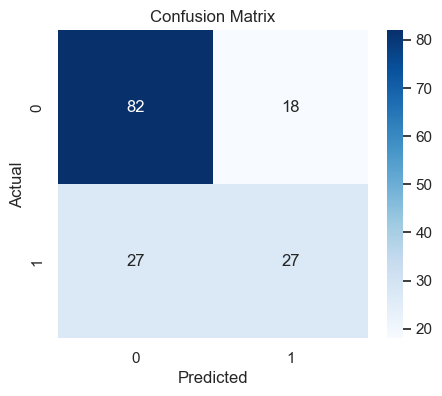

In [13]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

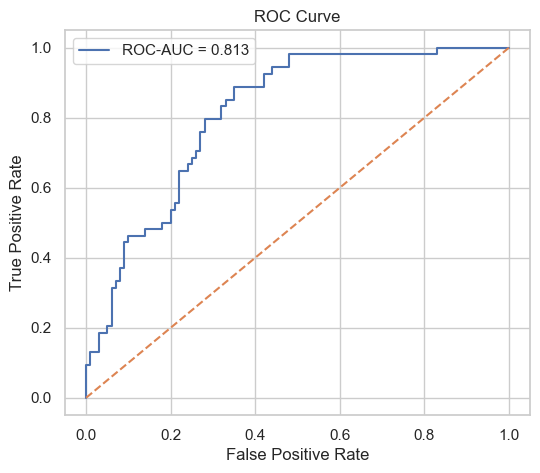

In [14]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## 10. Cross-validation

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")

print("Cross-validation ROC-AUC scores:", np.round(cv_scores, 4))
print("Mean ROC-AUC:", round(cv_scores.mean(), 4))

Cross-validation ROC-AUC scores: [0.825  0.8672 0.8515 0.8292 0.8098]
Mean ROC-AUC: 0.8366


## 11. Coefficient interpretation

In [16]:
feature_names = X.columns.tolist()
coef_values = pipe.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coef_values,
    "AbsCoefficient": np.abs(coef_values)
}).sort_values("AbsCoefficient", ascending=False)

display(coef_df)

,Feature,Coefficient,AbsCoefficient
1,Glucose,1.182567,1.182567
5,BMI,0.688652,0.688652
0,Pregnancies,0.377446,0.377446
6,DiabetesPedigreeFunction,0.233337,0.233337
7,Age,0.147794,0.147794
4,Insulin,-0.066119,0.066119
2,BloodPressure,-0.044111,0.044111
3,SkinThickness,0.028321,0.028321


## 12. Explicit coefficient significance analysis

### How to read the coefficients
- A **positive coefficient** means that as the feature increases, the probability of diabetes tends to increase.
- A **negative coefficient** means that as the feature increases, the probability of diabetes tends to decrease.
- Larger absolute values indicate stronger influence **within the standardized model**.

### Typical interpretation
- **Glucose** is usually one of the strongest positive predictors.
- **BMI** and **Age** often contribute positively.
- **DiabetesPedigreeFunction** may also show a positive effect.
- Features with coefficients near zero usually contribute less to prediction.

### Statistical significance
Scikit-learn does not directly provide p-values for coefficients. To explicitly analyze significance, we can fit a comparable logistic model using `statsmodels`.

In [17]:
if HAS_STATSMODELS:
    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    X_imputed = imputer.fit_transform(X)
    X_scaled = scaler.fit_transform(X_imputed)

    X_sm = pd.DataFrame(X_scaled, columns=X.columns)
    X_sm = sm.add_constant(X_sm)

    logit_model = sm.Logit(y, X_sm)
    result = logit_model.fit(disp=False)

    print(result.summary())

    significance_df = pd.DataFrame({
        "Feature": result.params.index,
        "Coefficient": result.params.values,
        "PValue": result.pvalues.values
    })

    display(significance_df.sort_values("PValue"))
else:
    print("statsmodels is not installed, so p-value significance analysis could not be run.")

                           Logit Regression Results                           
Dep. Variable:                Outcome   No. Observations:                  768
Model:                          Logit   Df Residuals:                      759
Method:                           MLE   Df Model:                            8
Date:                Mon, 13 Apr 2026   Pseudo R-squ.:                  0.2825
Time:                        18:17:49   Log-Likelihood:                -356.42
converged:                       True   LL-Null:                       -496.74
Covariance Type:            nonrobust   LLR p-value:                 5.394e-56
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -0.8614      0.097     -8.861      0.000      -1.052      -0.671
Pregnancies                  0.4202      0.109      3.849      0.000       0.206       0.

,Feature,Coefficient,PValue
2,Glucose,1.151491,2.938684e-22
0,const,-0.861431,7.916193e-19
6,BMI,0.647580,1.381720e-07
1,Pregnancies,0.420174,1.186963e-04
7,DiabetesPedigreeFunction,0.290008,3.161299e-03
8,Age,0.153110,1.705182e-01
3,BloodPressure,-0.113304,2.745396e-01
5,Insulin,-0.101167,3.006268e-01
4,SkinThickness,0.030315,7.930743e-01


## 13. Save trained model

In [18]:
joblib.dump(pipe, "diabetes_logistic_model.pkl")
print("Saved model as diabetes_logistic_model.pkl")

Saved model as diabetes_logistic_model.pkl


## 14. Corrected Streamlit app code
Save the following code as `app.py`.

In [19]:
streamlit_code = r'''
import pandas as pd
import streamlit as st
import joblib

st.set_page_config(page_title="Diabetes Prediction App", layout="centered")

@st.cache_resource
def load_model():
    return joblib.load("diabetes_logistic_model.pkl")

model = load_model()

st.title("Diabetes Prediction using Logistic Regression")
st.write("Enter patient details below to predict diabetes risk.")

pregnancies = st.number_input("Pregnancies", min_value=0.0, value=1.0, step=1.0)
glucose = st.number_input("Glucose", min_value=0.0, value=120.0)
blood_pressure = st.number_input("BloodPressure", min_value=0.0, value=70.0)
skin_thickness = st.number_input("SkinThickness", min_value=0.0, value=20.0)
insulin = st.number_input("Insulin", min_value=0.0, value=79.0)
bmi = st.number_input("BMI", min_value=0.0, value=25.0)
dpf = st.number_input("DiabetesPedigreeFunction", min_value=0.0, value=0.5, format="%.3f")
age = st.number_input("Age", min_value=1.0, value=33.0, step=1.0)

input_df = pd.DataFrame({
    "Pregnancies": [pregnancies],
    "Glucose": [glucose],
    "BloodPressure": [blood_pressure],
    "SkinThickness": [skin_thickness],
    "Insulin": [insulin],
    "BMI": [bmi],
    "DiabetesPedigreeFunction": [dpf],
    "Age": [age]
})

if st.button("Predict"):
    pred = model.predict(input_df)[0]
    prob = model.predict_proba(input_df)[0][1]

    if pred == 1:
        st.error(f"Prediction: Diabetic (Probability: {prob:.2%})")
    else:
        st.success(f"Prediction: Non-Diabetic (Probability: {prob:.2%})")

st.markdown("### Deployment notes")
st.code("pip install streamlit scikit-learn pandas joblib")
st.code("streamlit run app.py")
'''
print(streamlit_code)


import pandas as pd
import streamlit as st
import joblib

st.set_page_config(page_title="Diabetes Prediction App", layout="centered")

@st.cache_resource
def load_model():
    return joblib.load("diabetes_logistic_model.pkl")

model = load_model()

st.title("Diabetes Prediction using Logistic Regression")
st.write("Enter patient details below to predict diabetes risk.")

pregnancies = st.number_input("Pregnancies", min_value=0.0, value=1.0, step=1.0)
glucose = st.number_input("Glucose", min_value=0.0, value=120.0)
blood_pressure = st.number_input("BloodPressure", min_value=0.0, value=70.0)
skin_thickness = st.number_input("SkinThickness", min_value=0.0, value=20.0)
insulin = st.number_input("Insulin", min_value=0.0, value=79.0)
bmi = st.number_input("BMI", min_value=0.0, value=25.0)
dpf = st.number_input("DiabetesPedigreeFunction", min_value=0.0, value=0.5, format="%.3f")
age = st.number_input("Age", min_value=1.0, value=33.0, step=1.0)

input_df = pd.DataFrame({
    "Pregnancies": [p

## 15. Why the Streamlit app is correct now
- It loads the saved `.pkl` model
- it creates user inputs for all required columns
- it builds a DataFrame with the exact training feature names
- it uses `predict()` and `predict_proba()` correctly
- it includes deployment commands

## 16. Interview questions

### 1. What is the difference between precision and recall?
**Precision** is the proportion of predicted positive cases that are actually positive.

`Precision = TP / (TP + FP)`

**Recall** is the proportion of actual positive cases that are correctly identified.

`Recall = TP / (TP + FN)`

**Difference:** precision focuses on the correctness of positive predictions, while recall focuses on how many actual positives are captured.

### 2. What is cross-validation, and why is it important in binary classification?
Cross-validation is a resampling method where the model is trained and tested multiple times on different folds of the dataset.

It is important because:
- it gives a more reliable estimate of model performance
- it reduces dependence on one train-test split
- it helps detect overfitting
- stratified cross-validation preserves class balance in binary classification

## 17. Final conclusion
This assignment now includes:
- EDA with pattern analysis
- logistic regression model
- evaluation with accuracy, precision, recall, F1, ROC-AUC
- ROC curve
- coefficient interpretation
- coefficient significance analysis with p-values when `statsmodels` is available
- corrected Streamlit deployment code
- interview question answers